# SAE Pipeline — Full Run on Real Data (IU X-Ray + BiomedCLIP)

This notebook runs the full SAE (Sparse Autoencoder) pipeline on real embeddings
extracted from IU X-Ray chest radiographs via BiomedCLIP.

**Data** in `embeddings/`:
- `visual_embeddings.pt` — 7470 BiomedCLIP image embeddings (512-dim)
- `train_embeddings.pt` — ~5976 vectors (80% split)
- `test_embeddings.pt` — ~1494 vectors (20% split)
- `text_vocab_embeddings.pt` — vocabulary text embeddings (512-dim)

**Vocabulary** in `data/`:
- `vocabulary.json` — medical vocabulary labels (RadLex-derived)

**Pipeline stages:**
1. Train/Test Split
2. SAE Training (5 seeds, 50k steps)
3. Concept Naming
4. Generate Explanations
5. Stability Analysis
6. Visualization

## 0. Setup & Configuration

In [1]:
import sys
import json
import shutil
from pathlib import Path

import torch

# Resolve project root (3 levels up from this notebook)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"}')

Project root: /home/marcantoniolopez/Documenti/github/xai-project-5
PyTorch: 2.12.0+cu130
Device: cuda


In [2]:
import config

# Use default config (real data paths, full training)
# All paths come from config.paths (embeddings/, models/, results/, data/)
print('=== Configuration ===')
print(f'Embeddings:  {config.paths.embeddings_dir}')
print(f'Models:      {config.paths.models_dir}')
print(f'Results:     {config.paths.results_dir}')
print(f'Figures:     {config.paths.figures_dir}')
print(f'Vocab:       {config.paths.vocab_labels_path}')
print(f'Steps: {config.sae.steps}, Seeds: {config.training.seeds}')
print(f'Batch size: {config.sae.batch_size}, k: {config.sae.k}')
print(f'Device: {config.hardware.device}')

=== Configuration ===
Embeddings:  /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings
Models:      /home/marcantoniolopez/Documenti/github/xai-project-5/models
Results:     /home/marcantoniolopez/Documenti/github/xai-project-5/results
Figures:     /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures
Vocab:       /home/marcantoniolopez/Documenti/github/xai-project-5/data/vocabulary.json
Steps: 50000, Seeds: (0, 42, 123, 456, 789)
Batch size: 256, k: 32
Device: cuda


In [3]:
# Verify data exists
data_files = [
    ('visual_embeddings.pt', config.paths.visual_embeddings_path),
    ('train_embeddings.pt', config.paths.train_embeddings_path),
    ('test_embeddings.pt', config.paths.test_embeddings_path),
    ('text_vocab_embeddings.pt', config.paths.vocab_embeddings_path),
    ('vocabulary.json', config.paths.vocab_labels_path),
]

print('=== Data Verification ===')
all_ok = True
for name, path in data_files:
    exists = path.exists()
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {name} → {path}')
    if not exists:
        all_ok = False

if not all_ok:
    print('\n[WARNING] Some files are missing. Run prerequisite steps first:')
    print('    - extract_embeddings (visual + text vocab)')
    print('    - train/test split (autoencoder/train_sae.prepare_split)')

# Show shapes for existing files
print('\n=== Shapes ===')
for name, path in data_files:
    if path.exists():
        if path.suffix == '.pt':
            t = torch.load(path, map_location='cpu', weights_only=True)
            print(f'  {name}: {t.shape}')
        else:
            with open(path) as f:
                data = json.load(f)
            print(f'  {name}: {len(data)} items')

=== Data Verification ===
  [OK] visual_embeddings.pt → /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/visual_embeddings.pt
  [OK] train_embeddings.pt → /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/train_embeddings.pt
  [OK] test_embeddings.pt → /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/test_embeddings.pt
  [OK] text_vocab_embeddings.pt → /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/text_vocab_embeddings.pt
  [OK] vocabulary.json → /home/marcantoniolopez/Documenti/github/xai-project-5/data/vocabulary.json

=== Shapes ===
  visual_embeddings.pt: torch.Size([7470, 512])
  train_embeddings.pt: torch.Size([5976, 512])
  test_embeddings.pt: torch.Size([1494, 512])
  text_vocab_embeddings.pt: torch.Size([508, 512])
  vocabulary.json: 508 items


## 0.1 Train/Test Split

Creates `train_embeddings.pt` and `test_embeddings.pt` (80/20) from `visual_embeddings.pt`.
Skipped if the files already exist.

In [4]:
import utils

train_path = config.paths.train_embeddings_path
test_path = config.paths.test_embeddings_path

if train_path.exists() and test_path.exists():
    print('Split already present — skipping.')
    train_emb = utils.load_tensor(train_path)
    test_emb = utils.load_tensor(test_path)
else:
    print(f'Creating split from {config.paths.visual_embeddings_path} ...')
    # Propagate the image-id sidecar with the SAME permutation if present, so
    # each row keeps its image_id (needed downstream to join concepts to
    # reports.csv). Absent on older runs without the sidecar — skip cleanly.
    ids_kwargs = {}
    if config.paths.visual_image_ids_path.exists():
        ids_kwargs = {
            'source_ids_path': config.paths.visual_image_ids_path,
            'train_ids_path': config.paths.train_image_ids_path,
            'test_ids_path': config.paths.test_image_ids_path,
        }
    train_emb, test_emb = utils.split_embeddings(
        source_path=config.paths.visual_embeddings_path,
        train_path=train_path,
        test_path=test_path,
        train_ratio=config.training.train_split_ratio,
        seed=config.training.split_seed,
        **ids_kwargs,
    )
    print('Split saved' + (' (embeddings + image-id sidecars).' if ids_kwargs else '.'))

print(f'Train: {train_emb.shape}  →  {train_path}')
print(f'Test:  {test_emb.shape}  →  {test_path}')

/home/marcantoniolopez/Documenti/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split already present — skipping.
Train: torch.Size([5976, 512])  →  /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/train_embeddings.pt
Test:  torch.Size([1494, 512])  →  /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/test_embeddings.pt


## 1. SAE Training

Trains SAE models across all configured seeds (default: 5 seeds, 50k steps each).
Uses `config.paths.train_embeddings_path` as input.

In [5]:
from autoencoder.sae_module import SAEManager
from autoencoder.train_sae import compute_and_save_modality_gap

# Compute and save modality gap before training
compute_and_save_modality_gap()

trained_models = {}

for seed in config.training.seeds:
    print(f'\n--- Training seed={seed} ---')
    
    mgr = SAEManager({
        'device': config.hardware.device,
        'activation_dim': config.sae.activation_dim,
        'dict_size': config.sae.dict_size,
        'k': config.sae.k,
        'warmup_steps': config.sae.warmup_steps,
    })
    
    model_dir = mgr.train(
        embeddings_path=config.paths.train_embeddings_path,
        seed=seed,
        save_dir=config.paths.models_dir,
        steps=config.sae.steps,
        batch_size=config.sae.batch_size,
    )
    
    trained_models[seed] = model_dir
    print(f'Saved: {model_dir}')

18:02:29 | INFO | Modality gap already computed — skipping.
18:02:29 | INFO | Loaded 5976 embeddings from /home/marcantoniolopez/Documenti/github/xai-project-5/embeddings/train_embeddings.pt
18:02:29 | INFO | drop_last=True: 88 trailing samples skipped per epoch (step-based training cycles many epochs, so all data is seen).
18:02:29 | INFO | Training SAE (seed=0, steps=50000, lr=auto, decay_start=40000)...



--- Training seed=0 ---


  0%|          | 0/50000 [00:00<?, ?it/s]

Step 0: L0 = 32.0, frac_variance_explained = -0.5631816387176514


  2%|▏         | 1013/50000 [00:05<05:00, 163.09it/s]

...

Step 48000: L0 = 31.98046875, frac_variance_explained = 0.9925620555877686


 98%|█████████▊| 49032/50000 [04:00<00:03, 250.64it/s]

Step 49000: L0 = 32.0, frac_variance_explained = 0.9918980598449707


100%|██████████| 50000/50000 [04:06<00:00, 203.15it/s]
18:22:47 | INFO | Model saved to /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789
18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789


In [6]:
# Sanity checks on trained models
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)
print(f'Test embeddings: {test_emb.shape}')
print()

for seed, model_dir in trained_models.items():
    mgr = SAEManager({'device': config.hardware.device})
    mgr.load(model_dir)
    
    mse = mgr.compute_reconstruction_mse(test_emb)
    sparsity = mgr.compute_sparsity_metrics(test_emb)
    
    print(f'Seed {seed}:')
    print(f'  MSE:              {mse:.6f}')
    print(f'  L0 mean:          {sparsity["l0_mean"]:.1f} (expected: {config.sae.k})')
    print(f'  Dead features:    {sparsity["dead_features_pct"]:.1f}%')
    print(f'  Dict utilization: {sparsity["dict_utilization_pct"]:.1f}%')
    print()

18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed456/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:22:47 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Test embeddings: torch.Size([1494, 512])

Seed 0:
  MSE:              0.000046
  L0 mean:          32.0 (expected: 32)
  Dead features:    41.5%
  Dict utilization: 58.5%

Seed 42:
  MSE:              0.000044
  L0 mean:          32.0 (expected: 32)
  Dead features:    44.3%
  Dict utilization: 55.7%

Seed 123:
  MSE:              0.000046
  L0 mean:          32.0 (expected: 32)
  Dead features:    44.9%
  Dict utilization: 55.1%

Seed 456:
  MSE:              0.000044
  L0 mean:          32.0 (expected: 32)
  Dead features:    45.7%
  Dict utilization: 54.3%

Seed 789:
  MSE:              0.000045
  L0 mean:          32.0 (expected: 32)
  Dead features:    43.0%
  Dict utilization: 57.0%



In [7]:
# 1.3 Training & Test Loss Curves
# Train a fresh SAE with checkpoints to plot loss over training steps
import shutil
from dictionary_learning.trainers.top_k import AutoEncoderTopK, TopKTrainer
from dictionary_learning.training import trainSAE

CURVE_DIR = config.paths.models_dir / 'loss_curve'
if CURVE_DIR.exists():
    shutil.rmtree(CURVE_DIR)

train_emb = torch.load(config.paths.train_embeddings_path, map_location='cpu', weights_only=True)
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)

# Train with save_steps to get checkpoints
n_steps = config.sae.steps
checkpoint_steps = list(range(0, n_steps, 1000))  # every 1000 steps

def batch_gen():
    while True:
        perm = torch.randperm(len(train_emb))
        for i in range(0, len(perm), config.sae.batch_size):
            yield train_emb[perm[i:i+config.sae.batch_size]].to(config.hardware.device)

trainer_cfg = {
    "trainer": TopKTrainer,
    "activation_dim": config.sae.activation_dim,
    "dict_size": config.sae.dict_size,
    "k": config.sae.k,
    "steps": n_steps,
    "layer": 0,
    "lm_name": "biomedclip",
    "lr": config.sae.lr or 3e-4,
    "warmup_steps": config.sae.warmup_steps,
    "decay_start": int(n_steps * config.sae.decay_start_frac),
    "seed": config.training.primary_seed,
    "device": config.hardware.device,
}

print(f'Training SAE for {n_steps} steps with checkpoints every 1000 steps...')
trainSAE(
    data=batch_gen(),
    trainer_configs=[trainer_cfg],
    steps=n_steps,
    save_dir=str(CURVE_DIR),
    save_steps=checkpoint_steps,
    log_steps=config.sae.log_steps,
    device=config.hardware.device,
    normalize_activations=True,
    verbose=True,
)
print(f'Done. {len(checkpoint_steps)} checkpoints saved.')

Training SAE for 50000 steps with checkpoints every 1000 steps...


Calculating norm factor: 101it [00:00, 5302.00it/s]             


Average mean squared norm: 1.0
Norm factor: 1.0


  0%|          | 22/50000 [00:00<03:59, 208.81it/s]

Step 0: L0 = 32.0, frac_variance_explained = -0.5250061750411987


...

Step 48000: L0 = 32.0, frac_variance_explained = 0.9929338097572327


 98%|█████████▊| 49046/50000 [03:32<00:04, 225.60it/s]

Step 49000: L0 = 32.0, frac_variance_explained = 0.9922853112220764


100%|██████████| 50000/50000 [03:37<00:00, 230.33it/s]

Done. 50 checkpoints saved.


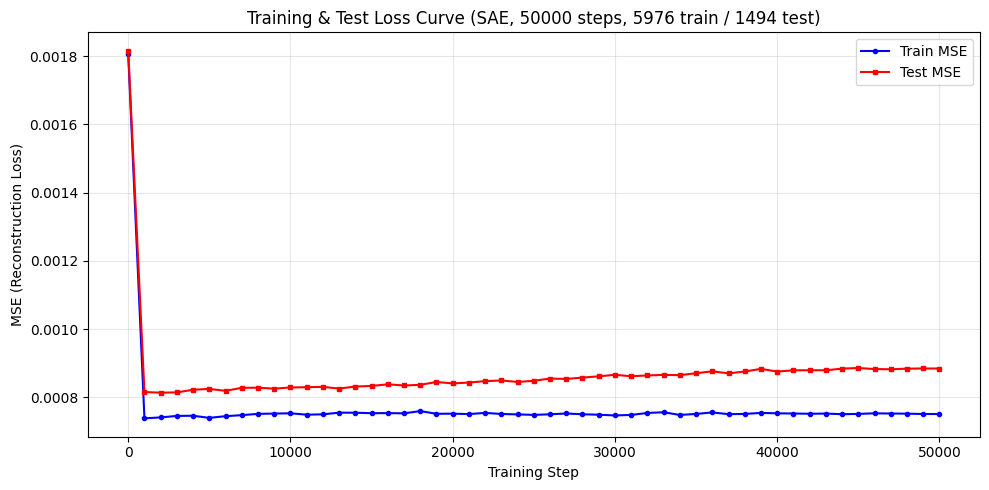

Step 0    → Train MSE: 0.0018, Test MSE: 0.0018
Step 50000 → Train MSE: 0.0008, Test MSE: 0.0009
Improvement: 58.4% (train), 51.3% (test)
Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/loss_curve.png


In [8]:
# Load each checkpoint and compute train/test MSE
import numpy as np
import matplotlib.pyplot as plt

checkpoint_dir = CURVE_DIR / 'trainer_0' / 'checkpoints'
final_path = CURVE_DIR / 'trainer_0' / 'ae.pt'

FIGURES_DIR = config.paths.figures_dir
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_losses = []
test_losses = []
steps_recorded = []

for step in checkpoint_steps:
    ckpt_path = checkpoint_dir / f'ae_{step}.pt'
    if ckpt_path.exists():
        ae = AutoEncoderTopK(config.sae.activation_dim, config.sae.dict_size, config.sae.k)
        ae.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=True))
        ae.eval()
        with torch.no_grad():
            train_recon = ae(train_emb)[0]
            test_recon = ae(test_emb)[0]
            train_mse = ((train_emb - train_recon) ** 2).mean().item()
            test_mse = ((test_emb - test_recon) ** 2).mean().item()
        train_losses.append(train_mse)
        test_losses.append(test_mse)
        steps_recorded.append(step)

# Also evaluate final model
ae = AutoEncoderTopK(config.sae.activation_dim, config.sae.dict_size, config.sae.k)
ae.load_state_dict(torch.load(final_path, map_location='cpu', weights_only=True))
ae.eval()
with torch.no_grad():
    train_recon = ae(train_emb)[0]
    test_recon = ae(test_emb)[0]
    train_mse_final = ((train_emb - train_recon) ** 2).mean().item()
    test_mse_final = ((test_emb - test_recon) ** 2).mean().item()
train_losses.append(train_mse_final)
test_losses.append(test_mse_final)
steps_recorded.append(n_steps)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps_recorded, train_losses, 'b-o', label='Train MSE', markersize=3)
ax.plot(steps_recorded, test_losses, 'r-s', label='Test MSE', markersize=3)
ax.set_xlabel('Training Step')
ax.set_ylabel('MSE (Reconstruction Loss)')
ax.set_title(f'Training & Test Loss Curve (SAE, {n_steps} steps, {len(train_emb)} train / {len(test_emb)} test)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Step 0    → Train MSE: {train_losses[0]:.4f}, Test MSE: {test_losses[0]:.4f}')
print(f'Step {n_steps:>4} → Train MSE: {train_losses[-1]:.4f}, Test MSE: {test_losses[-1]:.4f}')
print(f'Improvement: {(1 - train_losses[-1]/train_losses[0])*100:.1f}% (train), {(1 - test_losses[-1]/test_losses[0])*100:.1f}% (test)')
print(f'Saved: {FIGURES_DIR / "loss_curve.png"}')

## 2. Concept Naming

Assigns medical names to each of the 4096 SAE features using cosine similarity
between the decoder weights and the vocabulary embeddings.

In [9]:
# Load vocabulary
with open(config.paths.vocab_labels_path) as f:
    vocab_labels = json.load(f)

vocab_embeddings = torch.load(
    config.paths.vocab_embeddings_path, map_location='cpu', weights_only=True
)

print(f'Vocabulary: {len(vocab_labels)} terms')
print(f'Vocab embeddings: {vocab_embeddings.shape}')
print(f'First 10 terms: {vocab_labels[:10]}')

Vocabulary: 508 terms
Vocab embeddings: torch.Size([508, 512])
First 10 terms: [{'term': 'cardiomegaly', 'similarity_score': 0.958345, 'source': 'nih_chestxray14_seed'}, {'term': 'endotracheal tube', 'similarity_score': 0.928412, 'source': 'input_filtered'}, {'term': 'Hemidiaphragma', 'similarity_score': 0.926212, 'source': 'input_filtered'}, {'term': 'herniated mediastinal pleural sac sign', 'similarity_score': 0.919982, 'source': 'input_filtered'}, {'term': 'non-tunneled central venous catheter', 'similarity_score': 0.918838, 'source': 'input_filtered'}, {'term': 'pulmonary hemorrhage', 'similarity_score': 0.916583, 'source': 'input_filtered'}, {'term': 'interstitial lung disease', 'similarity_score': 0.915481, 'source': 'input_filtered'}, {'term': 'central venous catheter', 'similarity_score': 0.913964, 'source': 'input_filtered'}, {'term': 'pulmonary infarction', 'similarity_score': 0.912509, 'source': 'input_filtered'}, {'term': 'pleural thickening', 'similarity_score': 0.90928, '

In [10]:
from autoencoder.sae_module import SAEManager

# Naming with the primary model (seed 42)
primary_model_dir = config.paths.models_dir / f'sae_seed{config.training.primary_seed}'

mgr = SAEManager({'device': config.hardware.device})
mgr.load(primary_model_dir)

gap_path = config.paths.models_dir / 'modality_gap.pt'
modality_gap = torch.load(gap_path)

concept_names = mgr.name_concepts(
    vocab_embeddings, vocab_labels, top_n=config.explanation.concept_top_n,
    modality_gap=modality_gap
)

# Statistics
scores = [v['score'] for v in concept_names.values()]
print(f'Features named: {len(concept_names)}')
print(f'Mean score:     {sum(scores)/len(scores):.4f}')
print(f'Min/Max score:  {min(scores):.4f} / {max(scores):.4f}')

# Top-10
print('\nTop-10 concepts by score:')
sorted_concepts = sorted(concept_names.items(), key=lambda x: x[1]['score'], reverse=True)
for feat_id, info in sorted_concepts[:10]:
    print(feat_id)
    print(info)
#    print(f'  Feature {feat_id:>4}: {info["name"]:30s} (score={info["score"]:.4f})')

18:26:36 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Features named: 4096
Mean score:     0.3949
Min/Max score:  0.2815 / 0.5457

Top-10 concepts by score:
690
{'name': 'cricothyroid tube', 'score': 0.5456748008728027, 'candidates': [{'label': 'cricothyroid tube', 'score': 0.5456748008728027}, {'label': 'endotracheal tube', 'score': 0.5026658177375793}, {'label': 'splint', 'score': 0.4700373113155365}], 'is_dead': False}
1090
{'name': 'ligamentum flavum', 'score': 0.5229707956314087, 'candidates': [{'label': 'ligamentum flavum', 'score': 0.5229707956314087}, {'label': 'intervertebral foramen', 'score': 0.5180506706237793}, {'label': 'lumbar segment of spinal cord', 'score': 0.5036574602127075}], 'is_dead': False}
1806
{'name': 'moderate central spinal stenosis', 'score': 0.5191890597343445, 'candidates': [{'label': 'moderate central spinal stenosis', 'score': 0.5191890597343445}, {'label': 'mild central spinal stenosis', 'score': 0.4838612973690033}, {'label': 'central spinal stenosis', 'score': 0.4651164412498474}], 'is_dead': False}
38

In [11]:
# Save concept_names.json
config.paths.results_dir.mkdir(parents=True, exist_ok=True)
concept_names_path = config.paths.results_dir / 'concept_names.json'

with open(concept_names_path, 'w') as f:
    json.dump(concept_names, f, indent=2, ensure_ascii=False)

print(f'Saved: {concept_names_path}')
print(f'Size: {concept_names_path.stat().st_size / 1024:.1f} KB')

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/concept_names.json
Size: 1699.1 KB


## 3. Generate Explanations

For each test image, extracts the top-k activated concepts
and generates a structured pseudo-report for the LLM Judge.

In [12]:
from autoencoder.generate_explanations import generate_explanation

# Load test embeddings and concept_names
test_emb = torch.load(config.paths.test_embeddings_path, map_location='cpu', weights_only=True)

with open(concept_names_path) as f:
    concept_names_json = json.load(f)

# Extract top concepts for each test sample
mgr = SAEManager({'device': config.hardware.device})
mgr.load(primary_model_dir)

all_top_concepts = mgr.get_top_concepts(test_emb, n=config.explanation.explanation_top_n)
print(f'Test samples: {len(all_top_concepts)}')
print(f'Concepts per sample: {config.explanation.explanation_top_n}')

18:26:36 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


Test samples: 1494
Concepts per sample: 5


In [13]:
# Generate explanations
# Load per-row image ids (basename) for the test split so each explanation
# carries the image_id the LLM judge joins reports.csv on.
if config.paths.test_image_ids_path.exists():
    with open(config.paths.test_image_ids_path) as f:
        test_image_ids = json.load(f)
else:
    test_image_ids = None

explanations = []
for idx, top_concepts in enumerate(all_top_concepts):
    explanation = generate_explanation(top_concepts, concept_names_json)
    explanation['image_id'] = test_image_ids[idx] if test_image_ids else f'sample_{idx}'
    explanations.append(explanation)

print(f'Explanations generated: {len(explanations)}')
print()

# Show first 3 pseudo-reports
print('=== Sample Pseudo-Reports ===')
for i, exp in enumerate(explanations[:3]):
    print(f'\nSample {i} ({exp["image_id"]}):')
    print(f'  Report: {exp["pseudo_report"]}')
    print(f'  Concepts: {len(exp["top_k_concepts"])}')
    for c in exp['top_k_concepts'][:3]:
        print(f'    - {c["name"]} (act={c["activation"]:.3f})')

Explanations generated: 1494

=== Sample Pseudo-Reports ===

Sample 0 (3222_IM-1522-2001.dcm.png):
  Report: The model identifies the following visual concepts in this radiograph: intervertebral foramen, intervertebral foramen, progressive massive fibrosis, left coronary artery, ligamentum flavum. The dominant concept is 'intervertebral foramen' (activation=0.190).
  Concepts: 5
    - intervertebral foramen (act=0.190)
    - intervertebral foramen (act=0.176)
    - progressive massive fibrosis (act=0.139)

Sample 1 (1280_IM-0187-3001.dcm.png):
  Report: The model identifies the following visual concepts in this radiograph: iliac spine, ligamentum flavum, intervertebral foramen, intervertebral foramen, moderate central spinal stenosis. The dominant concept is 'iliac spine' (activation=0.170).
  Concepts: 5
    - iliac spine (act=0.170)
    - ligamentum flavum (act=0.164)
    - intervertebral foramen (act=0.158)

Sample 2 (3114_IM-1462-1003.dcm.png):
  Report: The model identifies the fo

In [14]:
# Save explanations
explanations_path = config.paths.results_dir / 'sample_explanations.json'
with open(explanations_path, 'w') as f:
    json.dump(explanations, f, indent=2, ensure_ascii=False)

print(f'Saved: {explanations_path}')
print(f'Size: {explanations_path.stat().st_size / 1024:.1f} KB')

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/sample_explanations.json
Size: 1407.1 KB


## 4. Stability Analysis

Compares activations from the 2 SAE models (different seeds) on the same samples.
Computes Jaccard similarity to measure concept stability across runs.

In [15]:
# Cross-seed Jaccard stability
model_dirs = [config.paths.models_dir / f'sae_seed{s}' for s in config.training.seeds]
print(f'Models: {[str(d.name) for d in model_dirs]}')

stability = SAEManager.compute_stability(
    model_dirs, test_emb, config={'device': config.hardware.device}
)

print(f'\nJaccard Matrix:')
print(stability['jaccard_matrix'])
print(f'\nMean Jaccard: {stability["mean_jaccard"]:.4f}')

Models: ['sae_seed0', 'sae_seed42', 'sae_seed123', 'sae_seed456', 'sae_seed789']


18:26:37 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:37 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:37 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:37 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed456/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)



Jaccard Matrix:
tensor([[1.0000, 0.0043, 0.0093, 0.0034, 0.0031],
        [0.0043, 1.0000, 0.0041, 0.0029, 0.0037],
        [0.0093, 0.0041, 1.0000, 0.0032, 0.0023],
        [0.0034, 0.0029, 0.0032, 1.0000, 0.0026],
        [0.0031, 0.0037, 0.0023, 0.0026, 1.0000]])

Mean Jaccard: 0.0039


In [16]:
# Per-seed metrics
print('=== Per-Seed Metrics ===')
per_seed_metrics = {}

for seed in config.training.seeds:
    mgr = SAEManager({'device': config.hardware.device})
    mgr.load(config.paths.models_dir / f'sae_seed{seed}')
    
    mse = mgr.compute_reconstruction_mse(test_emb)
    cosine = mgr.compute_cosine_reconstruction(test_emb)
    sparsity = mgr.compute_sparsity_metrics(test_emb)
    
    per_seed_metrics[seed] = {
        'mse': mse,
        'cosine': cosine,
        **sparsity,
    }
    
    print(f'\nSeed {seed}:')
    print(f'  MSE:              {mse:.6f}')
    print(f'  Cosine Sim:       {cosine:.4f}')
    print(f'  L0 mean:          {sparsity["l0_mean"]:.1f}')
    print(f'  Dead features:    {sparsity["dead_features_pct"]:.1f}%')
    print(f'  Dict utilization: {sparsity["dict_utilization_pct"]:.1f}%')
    print(f'  Entropy:          {sparsity["activation_entropy"]:.4f}')

18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed0/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed42/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)


=== Per-Seed Metrics ===

Seed 0:
  MSE:              0.000046
  Cosine Sim:       0.9882
  L0 mean:          32.0
  Dead features:    41.5%
  Dict utilization: 58.5%
  Entropy:          6.3955

Seed 42:
  MSE:              0.000044
  Cosine Sim:       0.9888
  L0 mean:          32.0
  Dead features:    44.3%
  Dict utilization: 55.7%
  Entropy:          6.3219


18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed123/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed456/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)
18:26:38 | INFO | Loaded SAE from /home/marcantoniolopez/Documenti/github/xai-project-5/models/sae_seed789/trainer_0/ae.pt (activation_dim=512, dict_size=4096, k=32)



Seed 123:
  MSE:              0.000046
  Cosine Sim:       0.9882
  L0 mean:          32.0
  Dead features:    44.9%
  Dict utilization: 55.1%
  Entropy:          6.3660

Seed 456:
  MSE:              0.000044
  Cosine Sim:       0.9887
  L0 mean:          32.0
  Dead features:    45.7%
  Dict utilization: 54.3%
  Entropy:          6.3529

Seed 789:
  MSE:              0.000045
  Cosine Sim:       0.9886
  L0 mean:          32.0
  Dead features:    43.0%
  Dict utilization: 57.0%
  Entropy:          6.3258


In [17]:
# Save stability results
stability_results = {
    'stability': {
        'mean_jaccard': stability['mean_jaccard'],
        'jaccard_matrix': stability['jaccard_matrix'].tolist(),
    },
    'per_seed_metrics': {str(k): v for k, v in per_seed_metrics.items()},
    'config': {
        'seeds': list(config.training.seeds),
        'n_test_samples': test_emb.shape[0],
        'steps': config.sae.steps,
    }
}

stability_path = config.paths.results_dir / 'stability_analysis.json'
with open(stability_path, 'w') as f:
    json.dump(stability_results, f, indent=2)

print(f'Saved: {stability_path}')

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/stability_analysis.json


## 5. Visualizations

Generate diagnostic plots for training quality and concept analysis.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from autoencoder.visualization import (
    plot_jaccard_heatmap,
    plot_concept_score_distribution,
    plot_per_seed_metrics,
    plot_sparsity_summary,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

FIGURES_DIR = config.paths.figures_dir
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures directory: {FIGURES_DIR}')

Figures directory: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures


18:26:40 | INFO | Saved concept score distribution to /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/concept_scores_dist.png


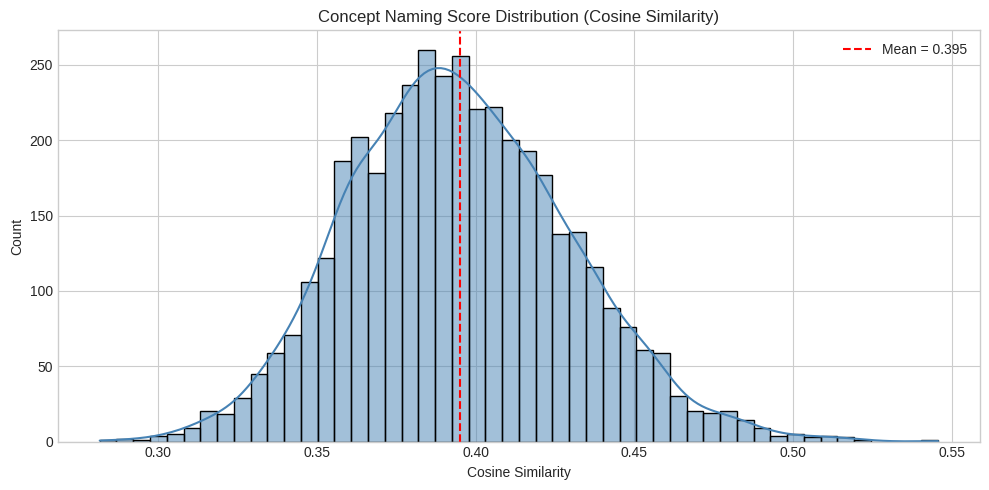

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/concept_scores_dist.png


In [19]:
# 5.1 Concept Naming Score Distribution
scores_array = [v['score'] for v in concept_names.values()]
plot_concept_score_distribution(scores_array, FIGURES_DIR / 'concept_scores_dist.png')

# Also display inline
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(scores_array, bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(np.mean(scores_array), color='red', linestyle='--', label=f'Mean = {np.mean(scores_array):.3f}')
ax.set_title('Concept Naming Score Distribution (Cosine Similarity)')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "concept_scores_dist.png"}')

18:26:40 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:26:40 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:26:40 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:26:40 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:26:40 | INFO | Saved per-seed metrics to /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/per_seed_metrics.png
18:26:40 | INFO | Using categoric

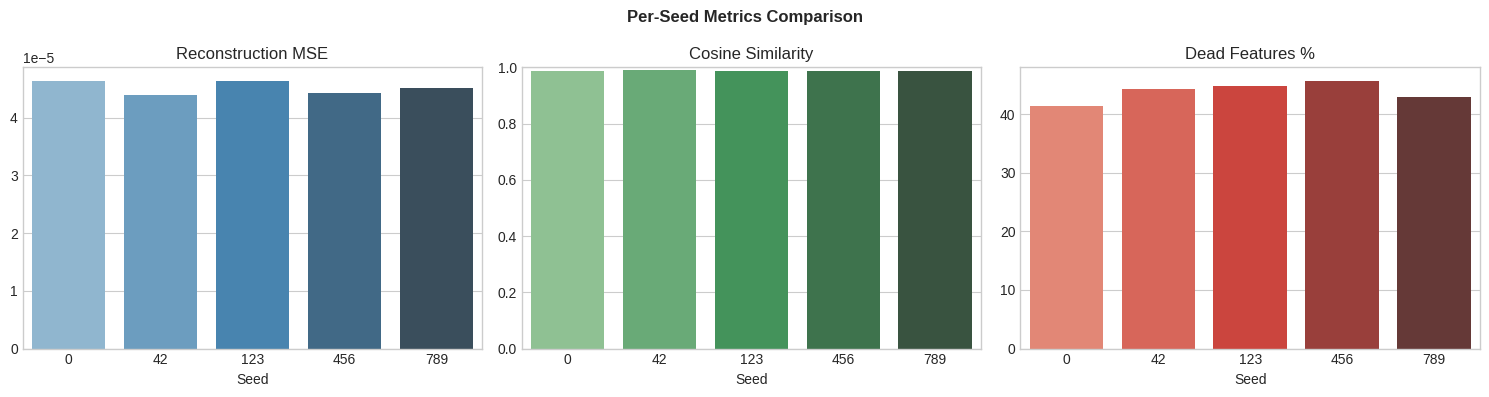

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/per_seed_metrics.png


In [20]:
# 5.2 Per-Seed Metrics Comparison (MSE and Dead Features)
plot_per_seed_metrics(per_seed_metrics, FIGURES_DIR / 'per_seed_metrics.png')

# Inline display
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
seeds_list = list(per_seed_metrics.keys())
mse_vals = [per_seed_metrics[s]['mse'] for s in seeds_list]
cosine_vals = [per_seed_metrics[s]['cosine'] for s in seeds_list]
dead_vals = [per_seed_metrics[s]['dead_features_pct'] for s in seeds_list]

sns.barplot(x=[str(s) for s in seeds_list], y=mse_vals, ax=axes[0], palette='Blues_d', hue=[str(s) for s in seeds_list], legend=False)
axes[0].set_title('Reconstruction MSE')
axes[0].set_xlabel('Seed')

sns.barplot(x=[str(s) for s in seeds_list], y=cosine_vals, ax=axes[1], palette='Greens_d', hue=[str(s) for s in seeds_list], legend=False)
axes[1].set_title('Cosine Similarity')
axes[1].set_xlabel('Seed')
axes[1].set_ylim(0, 1)

sns.barplot(x=[str(s) for s in seeds_list], y=dead_vals, ax=axes[2], palette='Reds_d', hue=[str(s) for s in seeds_list], legend=False)
axes[2].set_title('Dead Features %')
axes[2].set_xlabel('Seed')

fig.suptitle('Per-Seed Metrics Comparison', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "per_seed_metrics.png"}')

/tmp/ipykernel_184547/1435046151.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jaccard_matrix = np.array(stability['jaccard_matrix'])
18:26:40 | INFO | Saved Jaccard heatmap to /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/jaccard_heatmap.png


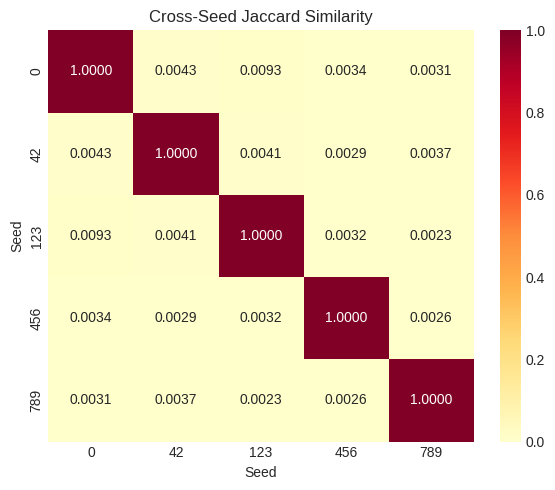

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/jaccard_heatmap.png


In [21]:
# 5.3 Jaccard Heatmap (Cross-Seed Stability)
jaccard_matrix = np.array(stability['jaccard_matrix'])
plot_jaccard_heatmap(jaccard_matrix, list(config.training.seeds), FIGURES_DIR / 'jaccard_heatmap.png')

# Inline display
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    jaccard_matrix,
    annot=True, fmt='.4f',
    xticklabels=[str(s) for s in config.training.seeds],
    yticklabels=[str(s) for s in config.training.seeds],
    cmap='YlOrRd', vmin=0, vmax=1, ax=ax
)
ax.set_title('Cross-Seed Jaccard Similarity')
ax.set_xlabel('Seed')
ax.set_ylabel('Seed')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "jaccard_heatmap.png"}')

18:26:41 | INFO | Saved sparsity summary to /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/sparsity_summary.png


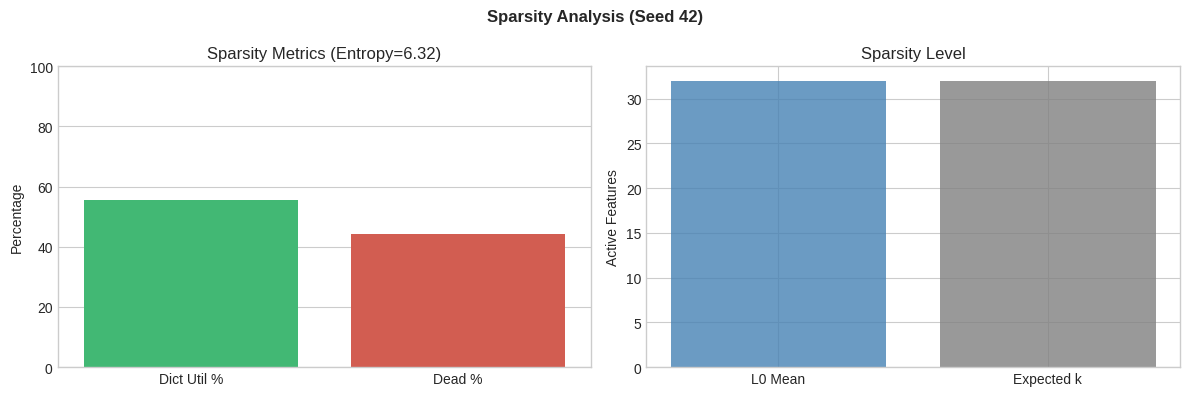

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/sparsity_summary.png


In [22]:
# 5.4 Sparsity Summary (primary seed)
primary_metrics = per_seed_metrics[config.training.primary_seed]
plot_sparsity_summary(
    dead_pct=primary_metrics['dead_features_pct'],
    utilization=primary_metrics['dict_utilization_pct'],
    entropy=primary_metrics['activation_entropy'],
    save_path=FIGURES_DIR / 'sparsity_summary.png',
)

# Inline display
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart
metrics_data = {
    'Dict Util %': primary_metrics['dict_utilization_pct'],
    'Dead %': primary_metrics['dead_features_pct'],
}
colors = ['#2ecc71' if v > 50 else '#e74c3c' for v in metrics_data.values()]
sns.barplot(x=list(metrics_data.keys()), y=list(metrics_data.values()), ax=axes[0],
            palette=colors, hue=list(metrics_data.keys()), legend=False)
axes[0].set_title(f'Sparsity Metrics (Entropy={primary_metrics["activation_entropy"]:.2f})')
axes[0].set_ylabel('Percentage')
axes[0].set_ylim(0, 100)

# Right: L0 distribution
axes[1].bar(['L0 Mean', 'Expected k'], [primary_metrics['l0_mean'], config.sae.k],
            color=['steelblue', 'gray'], alpha=0.8)
axes[1].set_title('Sparsity Level')
axes[1].set_ylabel('Active Features')

fig.suptitle(f'Sparsity Analysis (Seed {config.training.primary_seed})', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Saved: {FIGURES_DIR / "sparsity_summary.png"}')

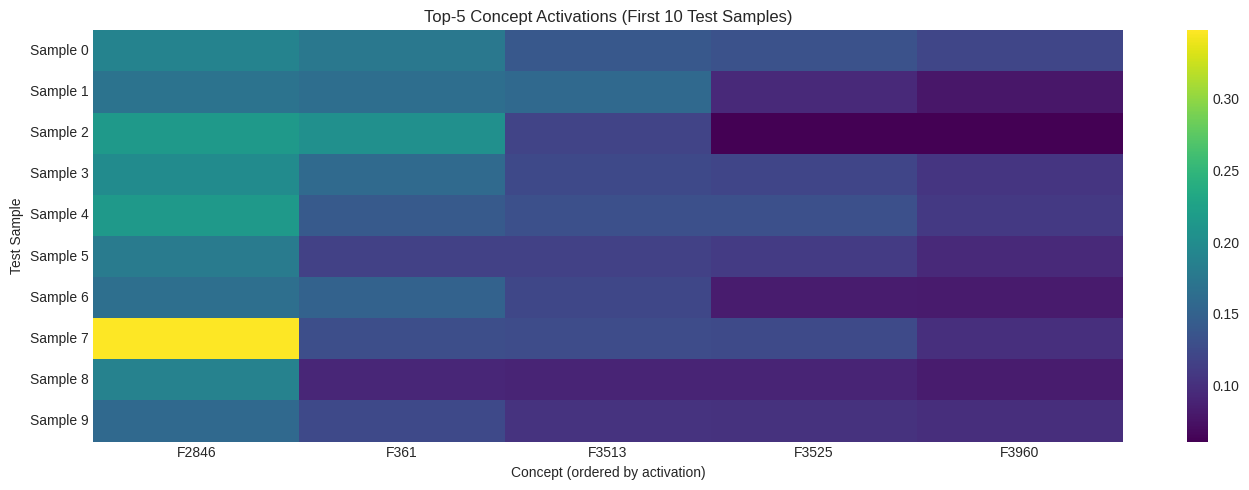

Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/concept_activations_heatmap.png


In [23]:
# 5.5 Top Concept Activations per Sample (heatmap)
# Show top-k activated features for first 10 test samples
n_show = min(10, len(all_top_concepts))
k_show = config.explanation.explanation_top_n

activation_matrix = np.zeros((n_show, k_show))
concept_labels = []
for i in range(n_show):
    for j, (feat_id, act_val) in enumerate(all_top_concepts[i][:k_show]):
        activation_matrix[i, j] = act_val
        if i == 0:
            name = concept_names.get(str(feat_id), {}).get('name', f'F{feat_id}')
            concept_labels.append(name[:15])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    activation_matrix,
    cmap='viridis',
    xticklabels=concept_labels if concept_labels else True,
    yticklabels=[f'Sample {i}' for i in range(n_show)],
    ax=ax,
)
ax.set_title(f'Top-{k_show} Concept Activations (First {n_show} Test Samples)')
ax.set_xlabel('Concept (ordered by activation)')
ax.set_ylabel('Test Sample')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'concept_activations_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "concept_activations_heatmap.png"}')

In [24]:
# 5.6 Loss Curve (via visualization module)
import importlib
import autoencoder.visualization
importlib.reload(autoencoder.visualization)
from autoencoder.visualization import plot_loss_curve

loss_curve_path = plot_loss_curve(
    steps=steps_recorded,
    train_losses=train_losses,
    test_losses=test_losses,
    save_path=FIGURES_DIR / 'loss_curve.png',
    title=f'Training & Test Loss Curve (SAE, {n_steps} steps, {len(train_emb)} train / {len(test_emb)} test)',
)
print(f'Saved: {loss_curve_path}')


18:26:41 | INFO | Saved loss curve to /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/loss_curve.png


Saved: /home/marcantoniolopez/Documenti/github/xai-project-5/results/figures/loss_curve.png


## 5.6 Weights & Biases Integration Test

Tests the `tracking.py` module by logging pipeline metrics to W&B.
Set `WANDB_ENABLED = True` below to actually log (requires `wandb login`).

In [25]:
WANDB_ENABLED = False  # Set to True only if you have already run `wandb login`

if WANDB_ENABLED:
    from autoencoder.tracking import init_tracking, log_metrics, log_artifact, finish_tracking

    # Initialize a W&B run
    init_tracking("sae-pipeline-real", {
        "project": "sae-concept-discovery",
        "seeds": list(config.training.seeds),
        "steps": config.sae.steps,
        "k": config.sae.k,
        "dict_size": config.sae.dict_size,
        "activation_dim": config.sae.activation_dim,
        "batch_size": config.sae.batch_size,
        "dataset": "IU X-Ray (BiomedCLIP)",
    })

    # Log loss curve (step-indexed)
    for step_i, (tr_loss, te_loss) in enumerate(zip(train_losses, test_losses)):
        log_metrics({
            "loss/train_mse": tr_loss,
            "loss/test_mse": te_loss,
        }, step=steps_recorded[step_i])

    # Log summary metrics
    for seed, metrics in per_seed_metrics.items():
        log_metrics({
            f"seed_{seed}/mse": metrics['mse'],
            f"seed_{seed}/cosine": metrics['cosine'],
            f"seed_{seed}/l0_mean": metrics['l0_mean'],
            f"seed_{seed}/dead_pct": metrics['dead_features_pct'],
            f"seed_{seed}/entropy": metrics['activation_entropy'],
        })

    log_metrics({
        "stability/mean_jaccard": stability['mean_jaccard'],
        "naming/mean_score": sum(scores_array) / len(scores_array),
        "naming/max_score": max(scores_array),
        "naming/min_score": min(scores_array),
    })

    # Log figures as artifacts
    for fig_path in sorted(FIGURES_DIR.glob('*.png')):
        log_artifact(fig_path, f"real-{fig_path.stem}", "figure")

    # Log result JSONs as artifacts
    log_artifact(config.paths.results_dir / 'concept_names.json', "concept-names", "results")
    log_artifact(config.paths.results_dir / 'stability_analysis.json', "stability", "results")

    finish_tracking()
    print('W&B run completed. Check your dashboard at https://wandb.ai')
else:
    print('W&B logging skipped (WANDB_ENABLED = False)')

W&B logging skipped (WANDB_ENABLED = False)


## 6. Summary

Final verification of all generated outputs.

In [26]:
print('=' * 50)
print('  PIPELINE COMPLETED SUCCESSFULLY')
print('=' * 50)
print()

# Models
print('Models:')
for seed in config.training.seeds:
    model_dir = config.paths.models_dir / f'sae_seed{seed}'
    ae_path = model_dir / 'trainer_0' / 'ae.pt'
    if not ae_path.exists():
        ae_path = model_dir / 'ae.pt'
    if ae_path.exists():
        size_mb = ae_path.stat().st_size / 1024 / 1024
        print(f'  sae_seed{seed}: {size_mb:.1f} MB')
    else:
        print(f'  sae_seed{seed}: NOT FOUND')

# Results
print('\nResults:')
for name in ['concept_names.json', 'sample_explanations.json', 'stability_analysis.json']:
    path = config.paths.results_dir / name
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f'  {name}: {size_kb:.1f} KB')
    else:
        print(f'  {name}: MISSING')

# Figures
print('\nFigures:')
for fig_path in sorted(FIGURES_DIR.glob('*.png')):
    size_kb = fig_path.stat().st_size / 1024
    print(f'  {fig_path.name}: {size_kb:.1f} KB')

  PIPELINE COMPLETED SUCCESSFULLY

Models:
  sae_seed0: 16.0 MB
  sae_seed42: 16.0 MB
  sae_seed123: 16.0 MB
  sae_seed456: 16.0 MB
  sae_seed789: 16.0 MB

Results:
  concept_names.json: 1699.1 KB
  sample_explanations.json: 1407.1 KB
  stability_analysis.json: 2.4 KB

Figures:
  concept_activations_heatmap.png: 52.0 KB
  concept_score_distribution.png: 58.7 KB
  concept_scores_dist.png: 57.8 KB
  jaccard_heatmap.png: 46.0 KB
  loss_curve.png: 55.2 KB
  per_seed_metrics.png: 37.4 KB
  sparsity_summary.png: 20.2 KB
